# 01 - EDA and Data Cleansing

This notebook starts the project with:
- Exploratory Data Analysis (EDA)
- Common-sense data cleansing
- Outlier review and practical treatment
- Initial modeling-ready export

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [2]:
DATA_PATH = '../cars.xlsx'
df = pd.read_excel(DATA_PATH)
print('shape:', df.shape)
df.head(3)

shape: (78025, 19)


,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
0,1641984,Car Accessories,Exterior Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,More than 1M,More than 25K,0 (No business),Unknown,0.69636,0.113985,0.154215,10K or less
1,1658010,Car Accessories,Exterior Accessories,Pacific,Reseller,63,Loss,2,163,163,0,250K to 500K,More than 25K,0 (No business),Unknown,0.00000,1.000000,0.000000,10K or less
2,1674737,Performance & Non-auto,Motorcycle Parts,Pacific,Reseller,24,Won,7,82,82,7750,100K or less,1K or less,0 (No business),Unknown,1.00000,0.000000,0.000000,10K or less


## 1) Dataset structure and missingness

In [3]:
dtypes = df.dtypes.rename('dtype').to_frame()
missing = df.isna().sum().rename('missing_count').to_frame()
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
profile = dtypes.join(missing).sort_values(['missing_pct', 'missing_count'], ascending=False)
profile

,dtype,missing_count,missing_pct
Competitor Type,str,9257,11.86
Opportunity Number,int64,0,0.00
Supplies Group,str,0,0.00
Supplies Subgroup,str,0,0.00
Region,str,0,0.00
Route To Market,str,0,0.00
Elapsed Days In Sales Stage,int64,0,0.00
Opportunity Result,str,0,0.00
Sales Stage Change Count,int64,0,0.00
Total Days Identified Through Closing,int64,0,0.00


## 2) Target analysis (classification + amount)

In [4]:
target_dist = (df['Opportunity Result']
               .value_counts(normalize=True)
               .mul(100)
               .round(2)
               .rename('pct'))
print('Opportunity Result distribution (%):')
print(target_dist)

amount_summary = df['Opportunity Amount USD'].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])
print('\nOpportunity Amount USD summary:')
print(amount_summary)

Opportunity Result distribution (%):
Opportunity Result
Loss    77.41
Won     22.59
Name: pct, dtype: float64

Opportunity Amount USD summary:
count      78025.000000
mean       91637.260750
std       133161.029156
min            0.000000
1%             0.000000
5%          1192.800000
50%        49000.000000
95%       350000.000000
99%       700000.000000
max      1000000.000000
Name: Opportunity Amount USD, dtype: float64


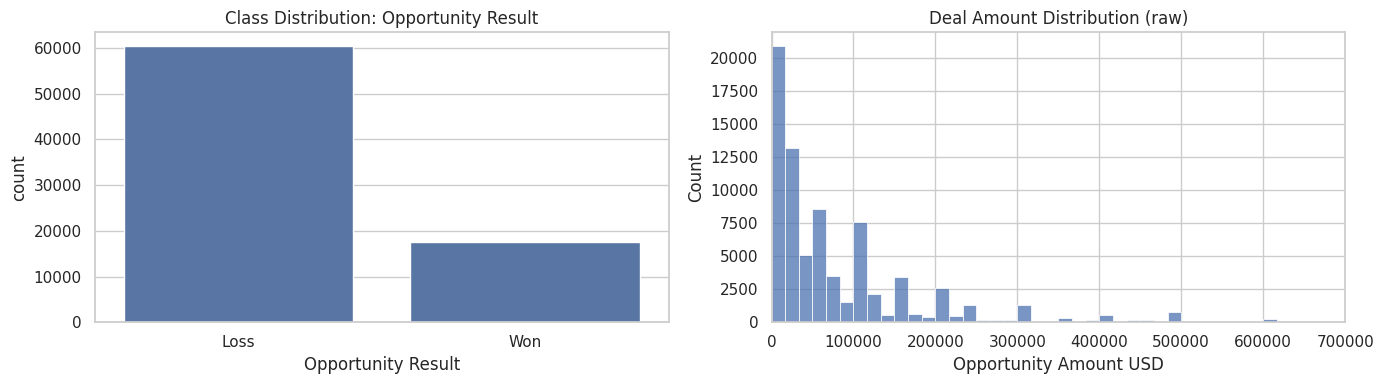

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x='Opportunity Result', order=df['Opportunity Result'].value_counts().index, ax=axes[0])
axes[0].set_title('Class Distribution: Opportunity Result')

sns.histplot(df['Opportunity Amount USD'], bins=60, kde=False, ax=axes[1])
axes[1].set_title('Deal Amount Distribution (raw)')
axes[1].set_xlim(0, df['Opportunity Amount USD'].quantile(0.99))
plt.tight_layout()

### Deal size category as additional target

To cover the second task from a categorical perspective, we also profile `Deal Size Category (USD)` as a target-like variable (classification framing).

In [6]:
deal_size_dist = (df['Deal Size Category (USD)']
    .value_counts(dropna=False)
    .rename('count')
    .to_frame())
deal_size_dist['pct'] = (deal_size_dist['count'] / len(df) * 100).round(2)
print('Deal Size Category (USD) distribution:')
display(deal_size_dist)

print('\nDeal Size Category x Opportunity Result:')
deal_size_vs_result = pd.crosstab(
    df['Deal Size Category (USD)'],
    df['Opportunity Result'],
    normalize='index'
).round(4)
display(deal_size_vs_result)

Deal Size Category (USD) distribution:


,count,pct
Deal Size Category (USD),,
40K to 50K,18074,23.16
10K to 20K,15123,19.38
30K to 40K,13628,17.47
10K or less,12095,15.50
20K to 30K,11968,15.34
50K to 60K,4934,6.32
More than 60K,2203,2.82



Deal Size Category x Opportunity Result:


Opportunity Result,Loss,Won
Deal Size Category (USD),,
10K or less,0.6006,0.3994
10K to 20K,0.7326,0.2674
20K to 30K,0.7533,0.2467
30K to 40K,0.8264,0.1736
40K to 50K,0.8827,0.1173
50K to 60K,0.8273,0.1727
More than 60K,0.7903,0.2097


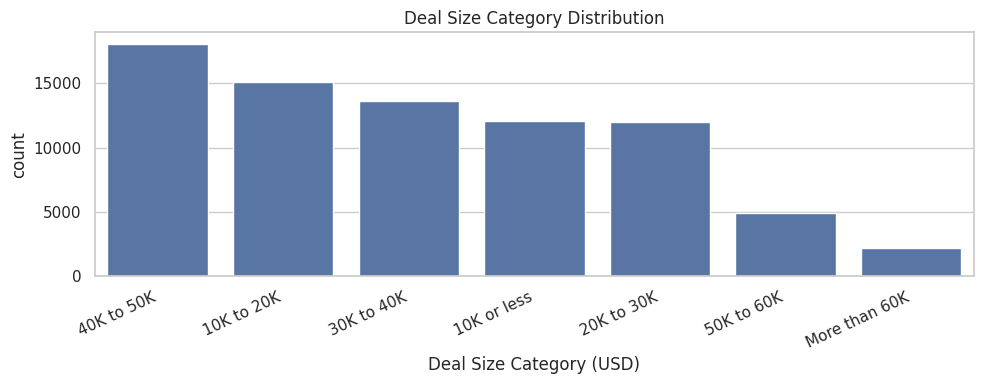

In [7]:
plt.figure(figsize=(10, 4))
order = df['Deal Size Category (USD)'].value_counts().index
sns.countplot(data=df, x='Deal Size Category (USD)', order=order)
plt.xticks(rotation=25, ha='right')
plt.title('Deal Size Category Distribution')
plt.tight_layout()

## 3) Funnel x segment insights

In [8]:
segment_win = (df.groupby(['Revenue From Client Past Two Years (USD)', 'Opportunity Result'])['Opportunity Number']
                 .count()
                 .unstack(fill_value=0))
segment_win['win_rate'] = (segment_win.get('Won', 0) / segment_win.sum(axis=1)).round(4)
segment_win.sort_values('win_rate', ascending=False)

Opportunity Result,Loss,Won,win_rate
Revenue From Client Past Two Years (USD),,,
"0 - 25,000",310,1472,0.8260
"25,000 - 50,000",548,1535,0.7369
"50,000 - 100,000",801,1291,0.6171
"More than 100,000",1520,1340,0.4685
0 (No business),57219,11989,0.1732


In [9]:
funnel_by_client = (df.groupby(['Client Size By Revenue (USD)', 'Opportunity Result'])['Elapsed Days In Sales Stage']
                    .median()
                    .unstack())
funnel_by_client

Opportunity Result,Loss,Won
Client Size By Revenue (USD),,
100K or less,34.0,35.0
100K to 250K,66.0,62.0
250K to 500K,65.0,64.0
500K to 1M,66.0,66.0
More than 1M,67.0,65.0


## 4) Common-sense cleansing decisions

In [10]:
clean = df.copy()

# Normalize text columns
obj_cols = clean.select_dtypes(include='object').columns
for c in obj_cols:
    clean[c] = clean[c].astype(str).str.strip()

# Restore true NaNs that became strings and handle missing competitor type
clean.replace({'nan': np.nan}, inplace=True)
clean['Competitor Type'] = clean['Competitor Type'].fillna('Unknown')

# Add strategic two-phase segment
clean['funnel_segment_2y'] = np.where(
    clean['Revenue From Client Past Two Years (USD)'].eq('0 (No business)'),
    'Reacquisition',
    'Engagement/Upselling'
)

# Binary target for classification
clean['target_win'] = clean['Opportunity Result'].map({'Won': 1, 'Loss': 0})

# Ensure no invalid win labels
invalid_labels = clean['target_win'].isna().sum()
print('invalid target labels:', invalid_labels)

clean.head(2)

invalid target labels: 0


/tmp/ipykernel_2595642/159904022.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = clean.select_dtypes(include='object').columns


,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD),funnel_segment_2y,target_win
0,1641984,Car Accessories,Exterior Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,More than 1M,More than 25K,0 (No business),Unknown,0.69636,0.113985,0.154215,10K or less,Reacquisition,1
1,1658010,Car Accessories,Exterior Accessories,Pacific,Reseller,63,Loss,2,163,163,0,250K to 500K,More than 25K,0 (No business),Unknown,0.00000,1.000000,0.000000,10K or less,Reacquisition,0


## 5) Outlier checks and treatment

## 6) Correlation analysis

Examine pairwise correlations among numeric features to spot multicollinearity and promising predictors.

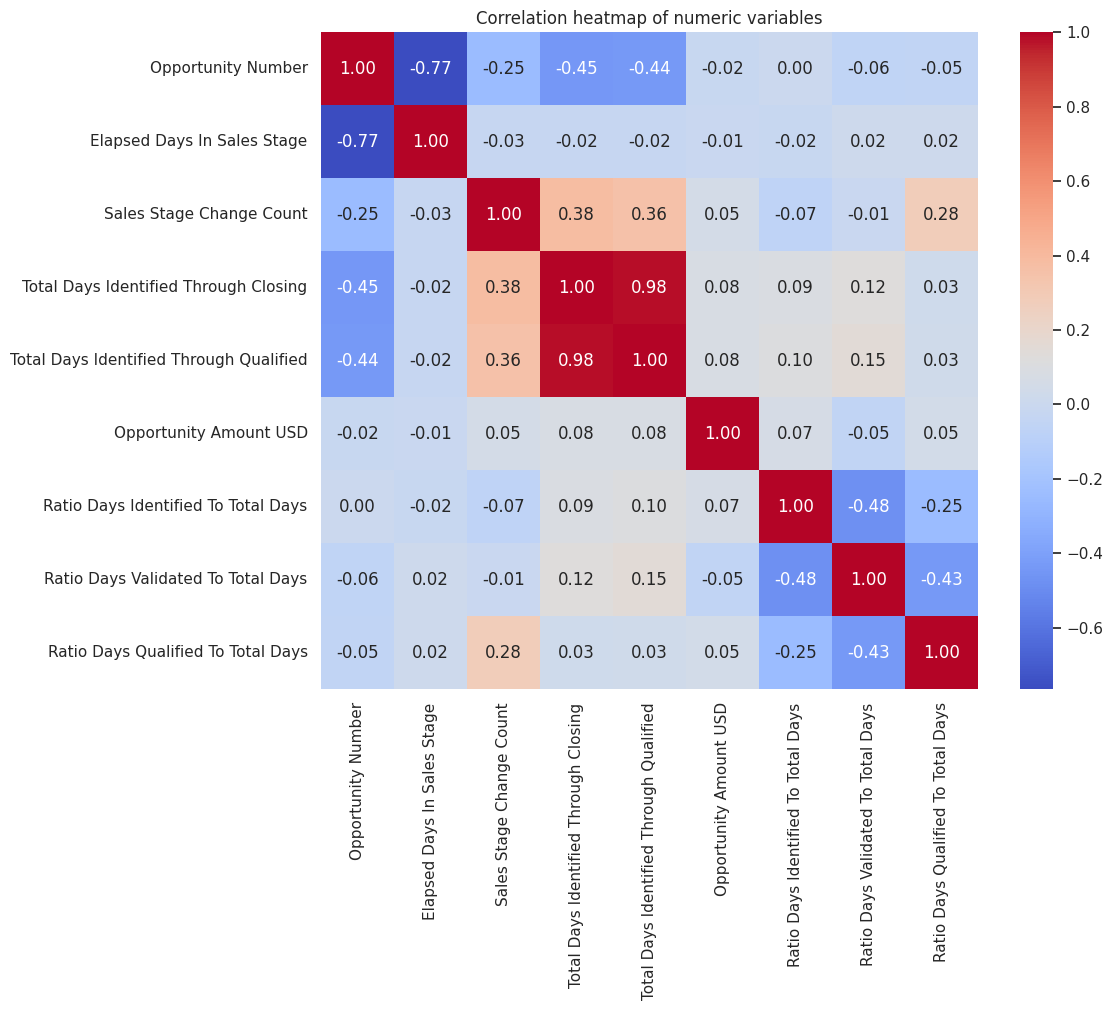

In [11]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap of numeric variables")
plt.tight_layout()


## 7) Numeric feature distributions

Visualize distributions and spot skewness/outliers for important metrics.

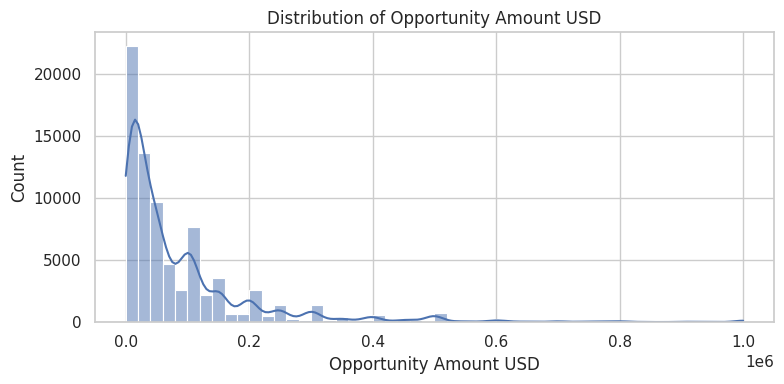

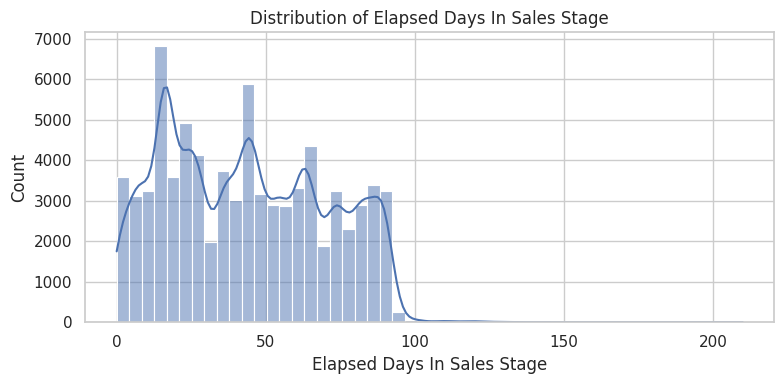

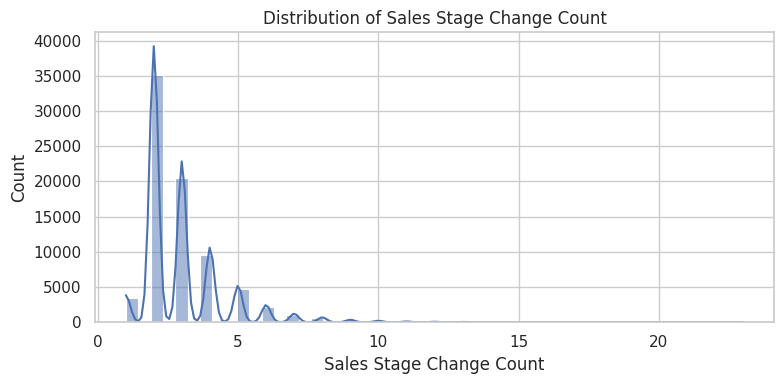

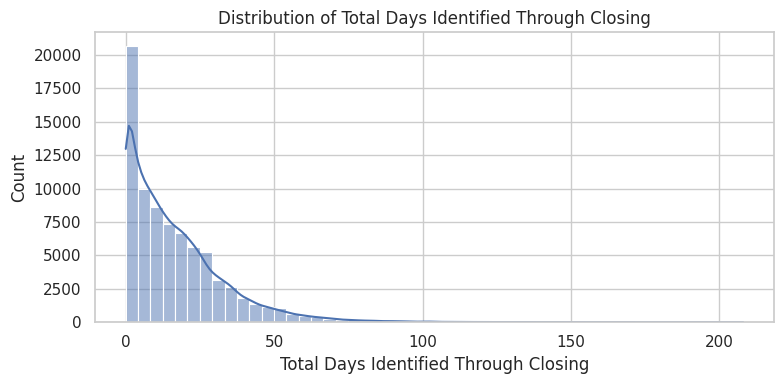

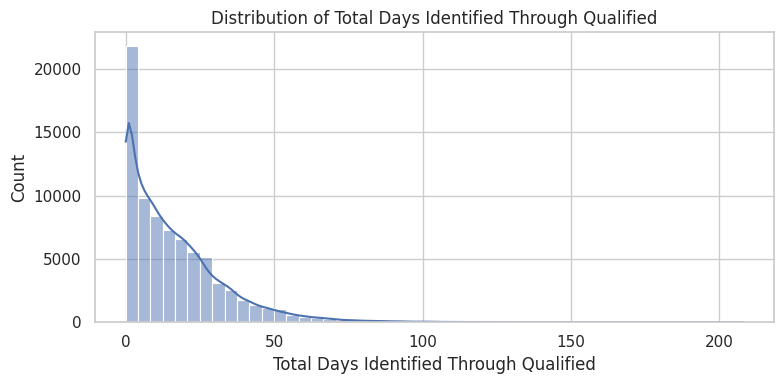

In [12]:
for col in ["Opportunity Amount USD", "Elapsed Days In Sales Stage", "Sales Stage Change Count", "Total Days Identified Through Closing", "Total Days Identified Through Qualified"]:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## 8) Deal amount by client segment

Boxplots to compare deal sizes across revenue segments.

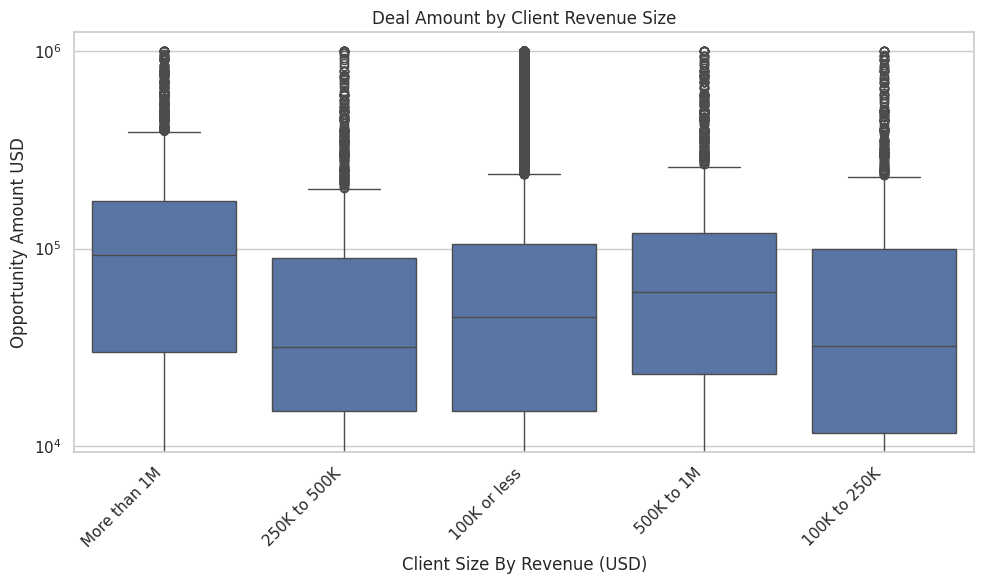

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Client Size By Revenue (USD)', y='Opportunity Amount USD')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Deal Amount by Client Revenue Size')
plt.tight_layout()


In [14]:
num_cols = [
    'Opportunity Amount USD',
    'Elapsed Days In Sales Stage',
    'Sales Stage Change Count',
    'Total Days Identified Through Closing',
    'Total Days Identified Through Qualified'
]

outlier_report = []
for c in num_cols:
    q1, q3 = clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    pct = ((clean[c] < low) | (clean[c] > high)).mean() * 100
    outlier_report.append({'column': c, 'iqr_low': low, 'iqr_high': high, 'outlier_pct': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('outlier_pct', ascending=False)
outlier_df

,column,iqr_low,iqr_high,outlier_pct
2,Sales Stage Change Count,0.5,4.5,11.97
0,Opportunity Amount USD,-120148.5,240247.5,9.32
3,Total Days Identified Through Closing,-26.0,54.0,3.47
4,Total Days Identified Through Qualified,-26.0,54.0,3.29
1,Elapsed Days In Sales Stage,-50.0,134.0,0.01


In [15]:
# Winsorize high-tail variables at P99 to reduce sensitivity to extreme values
for c in ['Opportunity Amount USD', 'Elapsed Days In Sales Stage', 'Sales Stage Change Count']:
    p99 = clean[c].quantile(0.99)
    clean[c + '_capped_p99'] = clean[c].clip(upper=p99)

# Add log-transform for amount modeling (handles zeros with log1p)
clean['log_opportunity_amount'] = np.log1p(clean['Opportunity Amount USD'])

clean[['Opportunity Amount USD', 'Opportunity Amount USD_capped_p99', 'log_opportunity_amount']].describe()

,Opportunity Amount USD,Opportunity Amount USD_capped_p99,log_opportunity_amount
count,78025.000000,78025.000000,78025.000000
mean,91637.260750,89982.785453,10.314292
std,133161.029156,123820.634989,2.291696
min,0.000000,0.000000,0.000000
25%,15000.000000,15000.000000,9.615872
50%,49000.000000,49000.000000,10.799596
75%,105099.000000,105099.000000,11.562668
max,1000000.000000,700000.000000,13.815512


## 6) Export cleaned dataset and quick recommendation

In [16]:
from pathlib import Path
OUTPUT_PATH = '../data/processed/cars_cleaned.parquet'
Path('../data/processed').mkdir(parents=True, exist_ok=True)
clean.to_parquet(OUTPUT_PATH, index=False)
print('saved:', OUTPUT_PATH)
print('clean shape:', clean.shape)

# Quick operational view
print('\nSegment split:')
print(clean['funnel_segment_2y'].value_counts(normalize=True).mul(100).round(2))

print('\nWin rate by 2-year segment:')
print(clean.groupby('funnel_segment_2y')['target_win'].mean().round(4))

saved: ../data/processed/cars_cleaned.parquet
clean shape: (78025, 25)

Segment split:
funnel_segment_2y
Reacquisition           88.7
Engagement/Upselling    11.3
Name: proportion, dtype: float64

Win rate by 2-year segment:
funnel_segment_2y
Engagement/Upselling    0.6394
Reacquisition           0.1732
Name: target_win, dtype: float64


## Initial proposal from this pass

1. Build a **win/loss classifier** with class balancing and probability calibration.
2. Build a **deal amount regressor** on `log_opportunity_amount` with de-biasing for high-value tails.
3. Prioritize pipeline actions by combining:
   - `P(win)` from classifier
   - expected amount from regressor
   - route/channel constraints for what-if simulations.
4. Start channel optimization with scenario tables by `Route To Market` x `funnel_segment_2y`.